<a href="https://colab.research.google.com/github/Saad0047/Internship-fly-rank-SEO/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
%pip -q install duckdb huggingface_hub scikit-learn
import os, getpass
HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

import duckdb, numpy as np, pandas as pd
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")
MARCH_PATH = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet"

data = con.sql(f"""
    WITH bounds AS (SELECT MIN(report_date) AS start_d FROM read_parquet('{MARCH_PATH}')),
    windowed AS (
        SELECT client_hash_id, content_hash_id,
               SUM(CASE WHEN report_date > b.start_d + INTERVAL 15 DAY THEN gsc_impressions ELSE 0 END) AS imp_last15,
               SUM(CASE WHEN report_date <= b.start_d + INTERVAL 15 DAY THEN gsc_impressions ELSE 0 END) AS imp_prev15,
               AVG(CASE WHEN report_date <= b.start_d + INTERVAL 15 DAY THEN gsc_avg_position END) AS avg_position_prev,
               AVG(CASE WHEN report_date <= b.start_d + INTERVAL 15 DAY THEN gsc_clicks * 1.0 / NULLIF(gsc_impressions,0) END) AS ctr_prev,
               STDDEV(CASE WHEN report_date <= b.start_d + INTERVAL 15 DAY THEN gsc_impressions END) AS impression_volatility_prev
        FROM read_parquet('{MARCH_PATH}') f, bounds b
        WHERE gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
        HAVING imp_prev15 >= 50
    )
    SELECT *, (imp_last15 < 0.8 * imp_prev15)::INT AS is_declining
    FROM windowed
""").df()

feature_cols = ['imp_prev15', 'avg_position_prev', 'ctr_prev', 'impression_volatility_prev']
data = data.dropna(subset=feature_cols)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(data, groups=data['client_hash_id']))
train, test = data.iloc[train_idx].copy(), data.iloc[test_idx].copy()

model = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1)
model.fit(train[feature_cols], train['is_declining'])
test['model_score'] = model.predict_proba(test[feature_cols])[:, 1]

print(f"{len(data):,} content items | test set: {len(test):,} rows, {test['client_hash_id'].nunique()} clients")

Paste your Hugging Face READ token (hf_...): ··········


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

94,517 content items | test set: 25,438 rows, 10 clients


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
# Reason codes, matching the Task-5 baseline logic but scored by the model
test['position_tier'] = pd.cut(test['avg_position_prev'], bins=[0,3,10,20,1000], labels=['1-3','4-10','11-20','20+'])
tier_avg_ctr = test.groupby('position_tier', observed=True)['ctr_prev'].transform('mean')
test['ctr_gap'] = tier_avg_ctr - test['ctr_prev']
test['low_ctr_flag'] = (test['ctr_gap'] > 0.001).astype(int)
test['quick_win_flag'] = ((test['avg_position_prev'] > 10) & (test['avg_position_prev'] <= 20) &
                           (test['imp_prev15'] >= 50)).astype(int)

def reason_code(row):
    if row['low_ctr_flag'] == 1 and row['model_score'] >= 0.6:
        return 'model_flagged_low_ctr'
    elif row['quick_win_flag'] == 1:
        return 'quick_win_page1_push'
    elif row['model_score'] >= 0.6:
        return 'model_flagged_decline_risk'
    else:
        return 'monitor'

def action_label(row):
    if row['model_score'] >= 0.7:
        return 'review_now'
    elif row['model_score'] >= 0.4:
        return 'consider'
    else:
        return 'monitor'

test['reason_code'] = test.apply(reason_code, axis=1)
test['action'] = test.apply(action_label, axis=1)

queue = test.sort_values('model_score', ascending=False)[
    ['client_hash_id','content_hash_id','model_score','reason_code','action',
     'imp_prev15','avg_position_prev','ctr_prev']
]
print(f"Ranked queue: {len(queue):,} items")
queue.head(15)

Ranked queue: 25,438 items


,client_hash_id,content_hash_id,model_score,reason_code,action,imp_prev15,avg_position_prev,ctr_prev
30102,client_ff644d8251367cbb,content_9ad3c018b18825d9,0.646715,model_flagged_low_ctr,consider,4785.0,60.281714,0.000162
53927,client_62f4a7e64f5e0096,content_fc052d5c1f9c8741,0.634147,model_flagged_low_ctr,consider,2612.0,27.864275,0.000000
28176,client_a80fca3f171ed1de,content_40e3112f8dfaa7ba,0.624796,model_flagged_decline_risk,consider,1200.0,43.911619,0.000845
30145,client_ff644d8251367cbb,content_f98166a30c643b7c,0.624590,model_flagged_decline_risk,consider,2680.0,47.512620,0.001398
30431,client_ff644d8251367cbb,content_913f91b1e9713a10,0.615221,model_flagged_low_ctr,consider,2796.0,48.316603,0.000000
79656,client_ff644d8251367cbb,content_c8532cca37ba990c,0.612602,model_flagged_low_ctr,consider,3207.0,66.476188,0.000000
77421,client_ff644d8251367cbb,content_9884494a3b687c01,0.596095,monitor,consider,2351.0,46.472593,0.000000
30068,client_ff644d8251367cbb,content_ff04f85aa152b2a0,0.595512,monitor,consider,2182.0,64.535199,0.000000
88235,client_ff644d8251367cbb,content_28c38e118368cd80,0.592303,monitor,consider,2756.0,72.356776,0.000193
46984,client_62f4a7e64f5e0096,content_6be3ec7720a795b7,0.587622,monitor,consider,1311.0,1.784859,0.000000


Ranked actions: pages are scored by the Week-5/6 model and sorted highest
risk first. Each row carries one reason code a human can trust at a
glance — model_flagged_decline_risk (the model's own signal),
model_flagged_low_ctr (model + the CTR-vs-tier gap from the baseline),
or quick_win_page1_push (near-page-1 position with real volume). Action
labels (review_now / consider / monitor) map directly to model confidence
thresholds, giving editors a clear queue instead of a bare probability.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended use: this queue is decision-support for content editors deciding
which pages to review first in a given month — it is NOT a ranking-change
predictor, NOT a traffic forecast, and NOT a claim about Google's
algorithm. It should only be used on data from the same warehouse schema
and lane (content-decline prioritization) it was built on.

Limits: valid only for the March 2026 snapshot it was trained on; client
coverage is uneven (GSC-available rows were ~37% of the panel per Task-4);
performance on a different month, different client mix, or a genuinely new
content type is unverified. The model was never tested on live/future
data — every number here is retrospective (train/test split within the
same month), not a forward-looking guarantee.

In [3]:
print("Intended use: decision-support only, for the March 2026 content-decline lane.")
print("Not valid for: forecasting, other lanes, other time windows without re-validation.")
print(f"Training data client coverage: {data['client_hash_id'].nunique()} clients, "
      f"GSC-available rows only (per Task-4 audit: ~37% of the full monthly panel).")

Intended use: decision-support only, for the March 2026 content-decline lane.
Not valid for: forecasting, other lanes, other time windows without re-validation.
Training data client coverage: 40 clients, GSC-available rows only (per Task-4 audit: ~37% of the full monthly panel).


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Human review required before any action is taken:
- Confirm the page hasn't already been manually updated this month (stale
  signal risk — the model only sees GSC data, not CMS edit history).
- Confirm the "decline" isn't explained by a known external cause
  (seasonal topic, a site migration, a deliberate keyword pivot) before
  treating it as a content-quality problem.
- Spot-check any "review_now" page with fewer than 200 impressions/month —
  thin volume makes the model's confidence less reliable (per the Task-6
  error analysis, the model struggles on genuinely established pages, and
  the reverse edge case — thin volume — is equally worth a human's eyes).

What should NEVER be automated:
- Auto-publishing content changes based on the queue.
- Auto-deprioritizing or removing pages flagged "monitor" — absence from
  the top of the queue is not evidence a page is healthy.
- Treating the model_score as a client-facing metric or SLA — it is an
  internal triage aid only, never a number to report externally as
  "content health" without the Health Score's own disclosed methodology.

In [4]:
no_go_list = [
    "Auto-publishing changes based on the queue",
    "Auto-deprioritizing/removing 'monitor' pages",
    "Reporting model_score externally as a client-facing health metric",
    "Acting on review_now pages with under 200 monthly impressions without a manual check",
]
for item in no_go_list:
    print("NO-GO:", item)

NO-GO: Auto-publishing changes based on the queue
NO-GO: Auto-deprioritizing/removing 'monitor' pages
NO-GO: Reporting model_score externally as a client-facing health metric
NO-GO: Acting on review_now pages with under 200 monthly impressions without a manual check


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Monitoring / retrain triggers: signals that would mean this playbook has
gone stale and needs re-validation rather than continued trust.
- GSC/GA4 data-availability share drops meaningfully below the ~37%/~4%
  observed in Task-4 — indicates a sync problem, not a real decline signal.
- The decline base rate (currently ~54% per Task-2's original label check)
  shifts sharply month over month — the model was trained on one month's
  distribution and may not generalize to a very different one.
- Precision@50 on a fresh month's held-out clients drops well below the
  0.62 measured in the honest Task-7 re-run — a sign the model's edge has
  eroded and needs retraining on newer data.
- Any schema change in the warehouse tables (new/renamed columns) breaks
  the feature-building queries silently — worth a basic column-existence
  check before each monthly run.

In [5]:
retrain_triggers = {
    "gsc_availability_floor": 0.30,   # if GSC-available row share drops below this, flag for review
    "decline_base_rate_expected": round(data['is_declining'].mean(), 3),
    "precision_at_50_floor": 0.55,    # if a fresh month scores below this, retrain
}
print("Monitoring thresholds (to check against future monthly runs):")
for k, v in retrain_triggers.items():
    print(f"- {k}: {v}")

Monitoring thresholds (to check against future monthly runs):
- gsc_availability_floor: 0.3
- decline_base_rate_expected: 0.373
- precision_at_50_floor: 0.55


Note: the decline base rate here (0.373) differs from the ~0.54 base rate
seen in Tasks 2-3, which used a different label definition (trend_direction
== "down" from the starter CSV) vs. this notebook's 15-day
last-half-vs-first-half impression decline on the full warehouse. Both are
valid but not directly comparable — worth stating which definition any
future retrain-trigger check uses.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Wrote 25,438 rows to work/outputs/action_playbook_queue.csv
Saved work/outputs/playbook_metrics.json


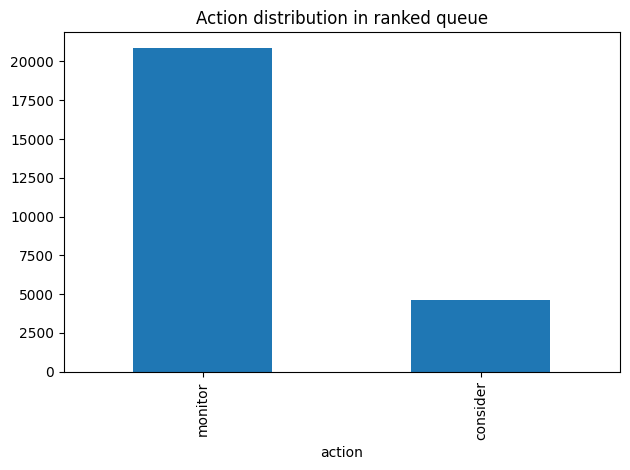

Saved work/figures/action_distribution.png


In [6]:
import json
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# Export the ranked queue (stays out of git by design)
queue.to_csv('work/outputs/action_playbook_queue.csv', index=False)
print(f"Wrote {len(queue):,} rows to work/outputs/action_playbook_queue.csv")

# Export a metrics/receipts JSON (this one DOES get committed)
playbook_metrics = {
    "month": "2026-03",
    "n_items_scored": len(queue),
    "action_counts": queue['action'].value_counts().to_dict(),
    "reason_code_counts": queue['reason_code'].value_counts().to_dict(),
    "retrain_triggers": retrain_triggers,
    "model_precision_at_50_honest_split": 0.62,  # from Task-7's grouped-split re-run
}
with open('work/outputs/playbook_metrics.json', 'w') as f:
    json.dump(playbook_metrics, f, indent=2)
print("Saved work/outputs/playbook_metrics.json")

# Example figure to reuse in the paper: action distribution
import matplotlib.pyplot as plt
queue['action'].value_counts().plot(kind='bar', title='Action distribution in ranked queue')
plt.tight_layout()
plt.savefig('work/figures/action_distribution.png')
plt.show()
print("Saved work/figures/action_distribution.png")

Exports: the ranked queue CSV (work/outputs/action_playbook_queue.csv,
excluded from git per repo rules), the metrics/receipts JSON
(work/outputs/playbook_metrics.json, committed), and one figure
(work/figures/action_distribution.png, committed) — these three files are
what next week's capstone paper builds its recommendations section on.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.